# Import des librairies et packages

In [1]:
import pandas as pd
import polars as pl
import polars.selectors as cs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
from sklearn.cluster import KMeans

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
)

In [3]:
from src.import_.read_file import  read_file, df_dtypes

from src.exploratory.explore_data import show_values_counts_columns, analyse_univariee_qualitative, describe_variables_numeriques, controle_regroupements_modalites, resume_production_pv_positive, separer_variables_quali_bin_quanti

from src.exploratory.plots import plot_pareto_modalites, plot_boxplot_and_hist, plot_target_dpe, plot_dist, boxplot_vs_target, plot_missing_train_test

from src.exploratory.bivariee import taux_energivore_par_modalite, tableau_quali_quali

from src.prepro.nettoyage import nettoyage_metier
from src.prepro.regrouper_modalites import creer_target_dpe_4_classes
from src.prepro.modalite_groupings import MODALITES_GROUPINGS
from src.prepro.regrouper_modalites import appliquer_regroupements_modalites

from src.prepro.prepro_ import split_train_test_polars, elbow_plot, fit_kmeans_pv_train, appliquer_kmeans_pv, colonnes_avec_missing, imputer_apres_selection, separer_colonnes_pipeline

from src.stats_.stats_ import tester_variables_avec_target

from src.models.models import afficher_classification_report, plot_confusion_matrix

In [4]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [5]:
PATH_DATA = "resources/dpe_hauts_de_france_2025-07-01_to_2025-12-31_half.csv"
TARGET = "etiquette_dpe"
CLASSES_DPE = ["A", "B", "C", "D", "E", "F", "G"]

DPE_COLORS = {
    "A": "#008A4B",
    "B": "#58B957",
    "C": "#C7D93D",
    "D": "#F4E04D",
    "E": "#F5A623",
    "F": "#E85D27",
    "G": "#C62828",
}

# Lecture et Visualisation des données

In [6]:
data, num_cols, cat_cols = read_file(PATH_DATA, TARGET)
df = data.clone()

### Import des données

Le jeu de données contient **57826 lignes** et **46 colonnes**.

### Réduction de la taille du DataFrame

Taille du DataFrame avant réduction : **37.71 MB**

Taille du DataFrame après réduction : **34.35 MB**

Réduction mémoire : **8.92%**

### Aperçu des données importées

etiquette_dpe,numero_dpe,date_etablissement_dpe,code_region_ban,code_departement_ban,code_postal_ban,code_insee_ban,nom_commune_ban,zone_climatique,classe_altitude,type_batiment,methode_application_dpe,periode_construction,annee_construction,surface_habitable_immeuble,nombre_niveau_immeuble,nombre_appartement,numero_etage_appartement,hauteur_sous_plafond,classe_inertie_batiment,qualite_isolation_enveloppe,qualite_isolation_murs,qualite_isolation_menuiseries,qualite_isolation_plancher_bas,qualite_isolation_plancher_haut_comble_perdu,type_installation_chauffage,type_installation_chauffage_n1,configuration_installation_chauffage_n1,type_generateur_chauffage_principal,type_generateur_n1_installation_n1,type_energie_principale_chauffage,type_energie_generateur_n1_installation_n1,type_emetteur_installation_chauffage_n1,usage_generateur_n1_installation_n1,type_installation_ecs,type_installation_ecs_n1,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal_ecs,type_energie_principale_ecs,type_energie_generateur_n1_ecs_n1,usage_generateur_n1_ecs_n1,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
str,str,str,u8,u8,u32,u32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f32,u8,str,f32
"""C""","""2559E3504406H""","""2025-11-05""",32,59,59320,59286,"""Haubourdin""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""1948-1974""",null,null,null,null,0.0,2.5,"""Lourde""","""très bonne""","""très bonne""","""bonne""","""très bonne""","""très bonne""",null,"""installation individuelle""","""Installation de chauffage simple""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur monotube sans robinet thermostatique sur réseau individuel eau chaude basse ou moyenne tem…","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,1,"""Non affecté""",0.0
"""F""","""2559E2432688J""","""2025-07-24""",32,59,59360,59136,"""Le Cateau-Cambrésis""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""avant 1948""",null,null,null,null,0.0,2.6,"""Lourde""","""insuffisante""","""insuffisante""","""moyenne""","""insuffisante""",null,null,"""installation individuelle""","""Installation de chauffage simple""",null,"""Chaudière gaz à condensation 2001-2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur bitube avec robinet thermostatique sur réseau individuel eau chaude haute température(sup …","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation 2001-2015""",null,"""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,0,"""Non affecté""",0.0
"""C""","""2502E3087497D""","""2025-09-30""",32,2,2170,2558,"""Le Nouvion-en-Thiérache""","""H1a""","""inférieur à 400m""","""appartement""","""dpe appartement individuel""","""1978-1982""",null,512.299988,null,1.0,0.0,2.5,"""Moyenne""","""très bonne""","""insuffisante""","""très bonne""","""insuffisante""",null,"""individuel""","""installation individuelle""","""Installation de chauffage simple""",null,"""Panneau rayonnant électrique NFC, NF** et NF***""","""Électricité""","""Électricité""","""Panneau rayonnant NFC, NF** et NF***""","""chauffage""","""individuel""","""installation individuelle""","""Un seul système d'ECS sans solaire""","""CET sur air ambiant (sur local non chauffé) après 2014""",null,"""Électricité""","""Électricité""","""ecs""",150.0,1,"""Non affecté""",0.0
"""E""","""2502E3013330O""","""2025-09-23""",32,2,2000,2408,"""Laon""","""H1a""","""inférieur à 400m""","""maison"""

### Que vaut notre target ?

etiquette_dpe,Pourcentage
str,f64
"""A""",0.94
"""B""",3.26
"""C""",36.12
"""D""",35.52
"""E""",15.03
"""F""",6.1
"""G""",3.03


In [7]:
df_dtypes(df)

### Les différents types du df

Variables,Types
str,str
"""etiquette_dpe""","""String"""
"""numero_dpe""","""String"""
"""date_etablissement_dpe""","""String"""
"""code_region_ban""","""UInt8"""
"""code_departement_ban""","""UInt8"""
"""code_postal_ban""","""UInt32"""
"""code_insee_ban""","""UInt32"""
"""nom_commune_ban""","""String"""
"""zone_climatique""","""String"""


### Catégorisation des types du df

Type,Nombre,Pourcentage
object,i64,f64
String,33,71.74
UInt8,3,6.52
UInt32,2,4.35
Float32,8,17.39


In [8]:
show_values_counts_columns(df)

### Modalités distinctes et valeurs manquantes par variable

Variable,Nombre de lignes,% valeurs manquantes,Modalités distinctes,% modalités distinctes
str,i64,f64,i64,f64
"""nombre_niveau_immeuble""",57826,76.42,19,0.03
"""surface_habitable_immeuble""",57826,68.46,3858,6.67
"""type_generateur_chauffage_principal_ecs""",57826,67.75,73,0.13
"""type_generateur_chauffage_principal""",57826,67.67,93,0.16
"""qualite_isolation_plancher_haut_comble_perdu""",57826,52.86,4,0.01
"""annee_construction""",57826,51.93,204,0.35
"""nombre_appartement""",57826,50.91,135,0.23
"""type_installation_chauffage""",57826,47.75,3,0.01
"""type_installation_ecs""",57826,47.75,3,0.01


# Première suppression de variables

In [9]:
var_to_drop1 = ["nombre_niveau_immeuble", "surface_habitable_immeuble", "type_generateur_chauffage_principal_ecs", "type_generateur_chauffage_principal", "qualite_isolation_plancher_haut_comble_perdu", "annee_construction", "nombre_appartement", "type_installation_chauffage", "type_installation_ecs", ]

var_const = ["numero_dpe"]

var_dpe = ["methode_application_dpe", "date_etablissement_dpe"]

var_id = ["code_region_ban", "code_departement_ban", "code_postal_ban", "code_insee_ban", "nom_commune_ban"]

var_to_drop = [*var_const, *var_dpe, *var_id]

cat_cols = list(set(cat_cols) - {*var_to_drop, *var_to_drop1})
num_cols = list(set(num_cols) - {*var_to_drop, *var_to_drop1})

In [10]:
df = df.drop(var_to_drop1)

In [11]:
CAT_VAR_TO_ANALYSE = ["zone_climatique", "type_batiment", "type_energie_principale_chauffage"]

NUM_VAR_TO_ANALYSE = ["numero_etage_appartement", "production_electricite_pv_kwhep_par_an", "hauteur_sous_plafond"]


# Analyse univariée

## Variables catégorielles

In [12]:
analyse_univariee_qualitative(df, col="zone_climatique")

## Analyse univariée : `zone_climatique`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **8**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

zone_climatique,Pourcentage
str,f64
"""H1a""",99.86
"""H3""",0.05
"""H1b""",0.03
"""H1c""",0.03
"""H2a""",0.01
"""H2c""",0.01
"""H2b""",0.01
"""H2d""",0.0


In [13]:
analyse_univariee_qualitative(df, col="type_energie_principale_chauffage")

## Analyse univariée : `type_energie_principale_chauffage`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **11**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

type_energie_principale_chauffage,Pourcentage
str,f64
"""Gaz naturel""",53.58
"""Électricité""",31.57
"""Réseau de Chauffage urbain""",7.89
"""Fioul domestique""",3.22
"""Bois – Granulés (pellets) ou briquettes""",1.74
"""Bois – Bûches""",1.49
"""GPL""",0.3
"""Charbon""",0.1
"""Propane""",0.09


In [14]:
var_doublons = ["type_energie_generateur_n1_installation_n1", "type_energie_generateur_n1_ecs_n1"]

var_to_drop = [*var_to_drop, *var_doublons]

In [15]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_chauffage")
            == pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_chauffage")
            != pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_chauffage").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_installation_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57522,278,0,26


In [16]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_ecs")
            == pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_ecs")
            != pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_ecs").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_ecs_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57557,42,0,227


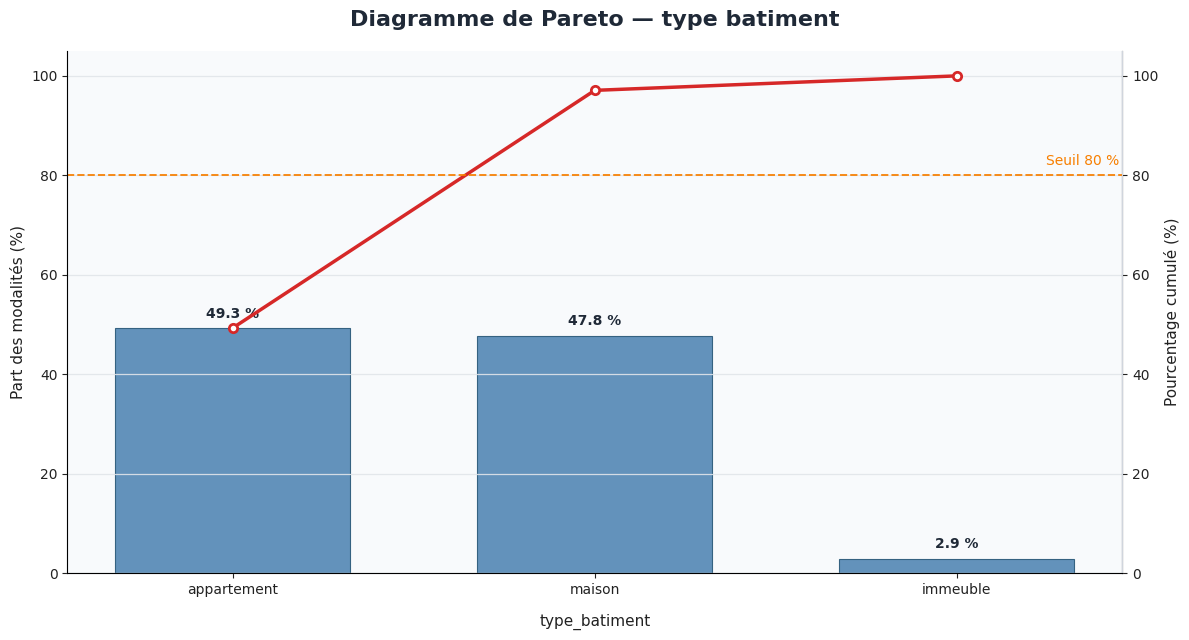

WindowsPath('src/plots/cat/pareto_type_batiment.png')

In [17]:
plot_pareto_modalites(df, col="type_batiment", top_n=10)

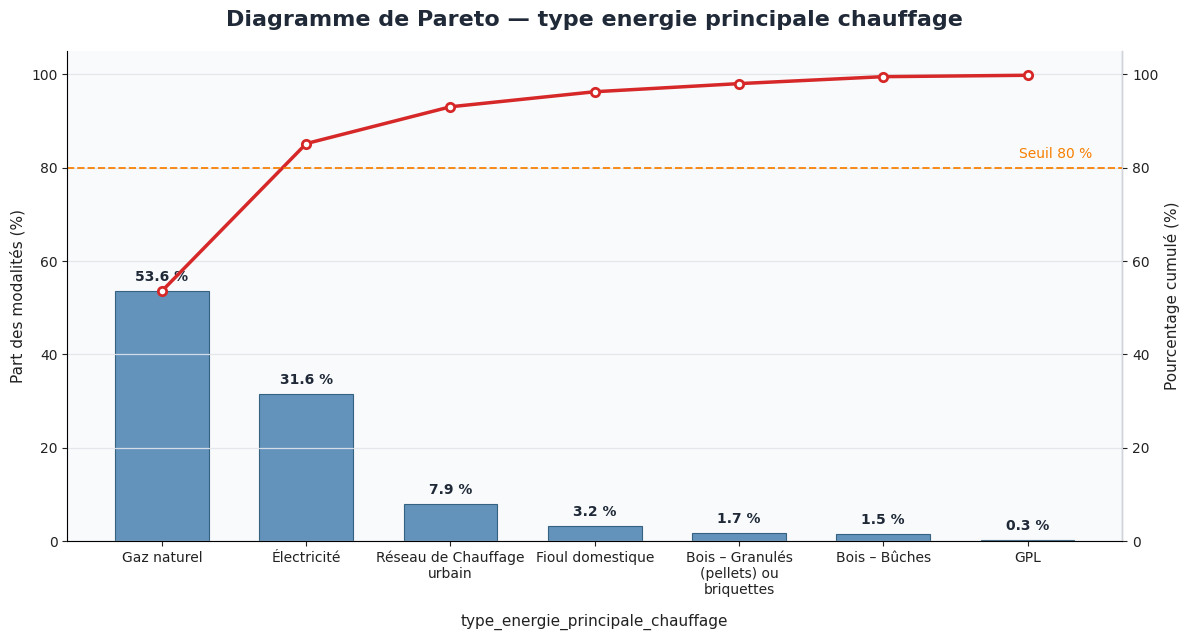

WindowsPath('src/plots/cat/pareto_type_energie_principale_chauffage.png')

In [18]:
plot_pareto_modalites(df, col="type_energie_principale_chauffage", top_n=7)

## Variables numériques

In [19]:
var_binaire = ["ventilation_posterieure_2012"]

num_cols = list(set(num_cols) - {*var_binaire, *var_id})
outlier_cols = describe_variables_numeriques(df, num_cols)


### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""hauteur_sous_plafond""",57826,0,0.0,61,2.562,1.727,1.0,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16546,28.61
"""production_electricite_pv_kwhep_par_an""",57826,0,0.0,399,42.724,1980.189,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,586,1.01
"""numero_etage_appartement""",51558,6268,10.84,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3493,6.04
"""volume_stockage_generateur_n1_ecs_n1""",57599,227,0.39,773,93.848,228.659,0.0,0.0,0.0,150.0,10000.0,150.0,-225.0,375.0,827,1.43


In [20]:
num_cols

['hauteur_sous_plafond',
 'production_electricite_pv_kwhep_par_an',
 'numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1']

### Visualisation des variables numériques

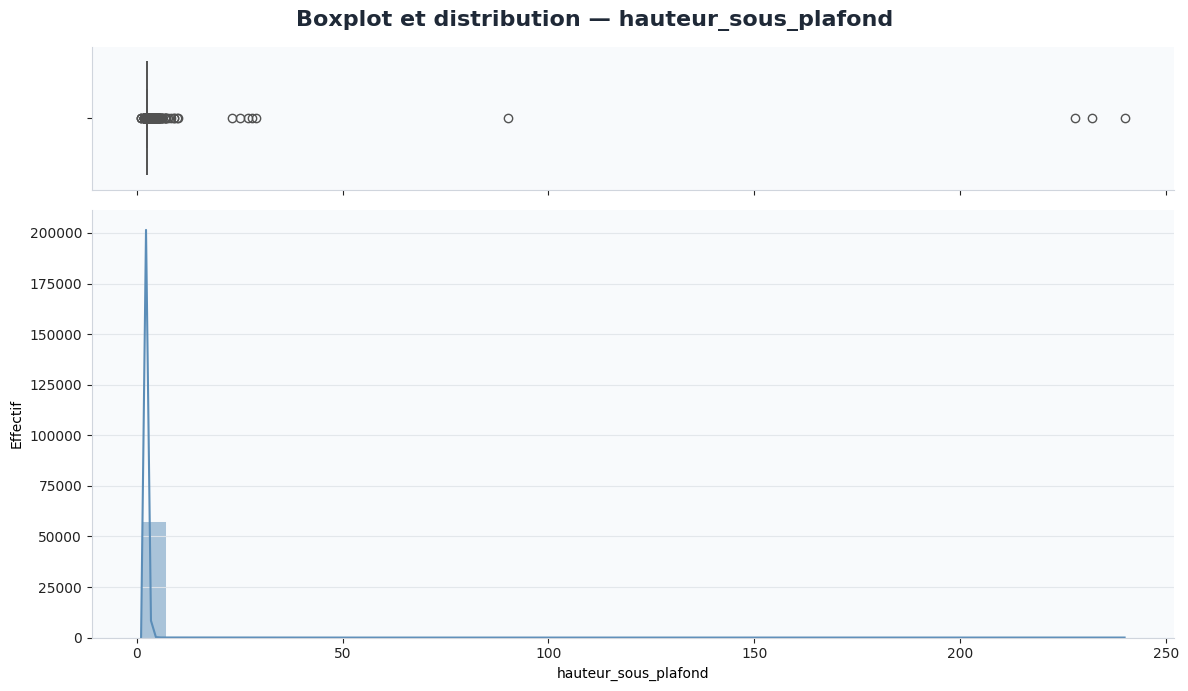

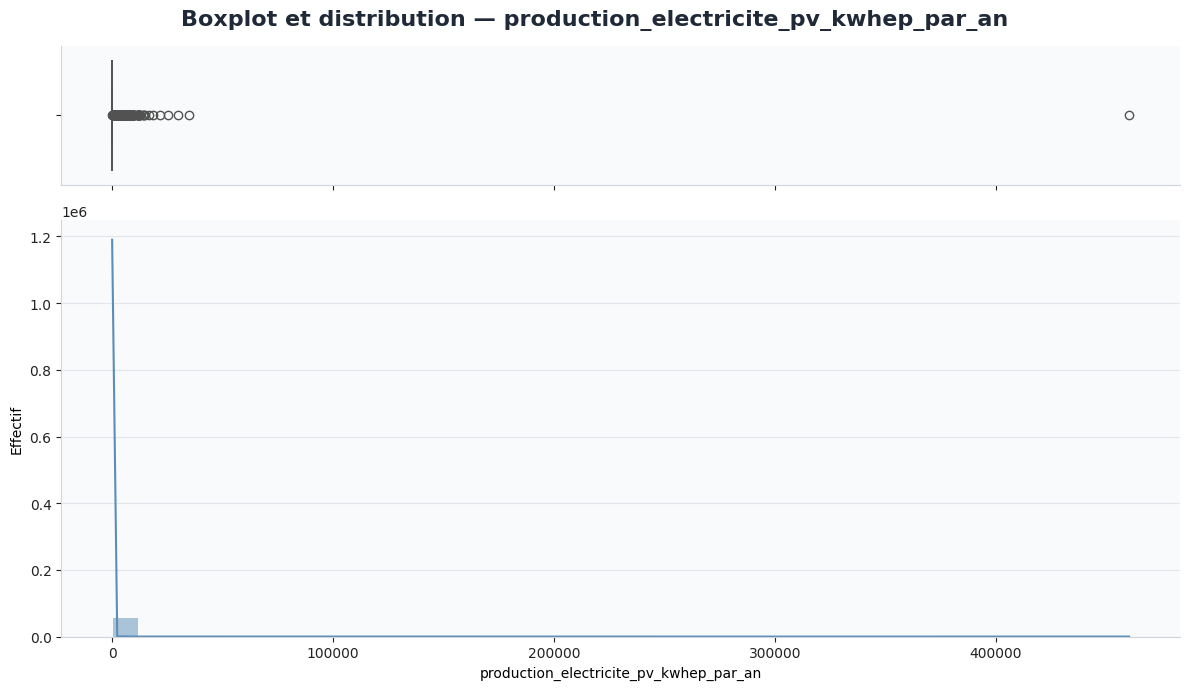

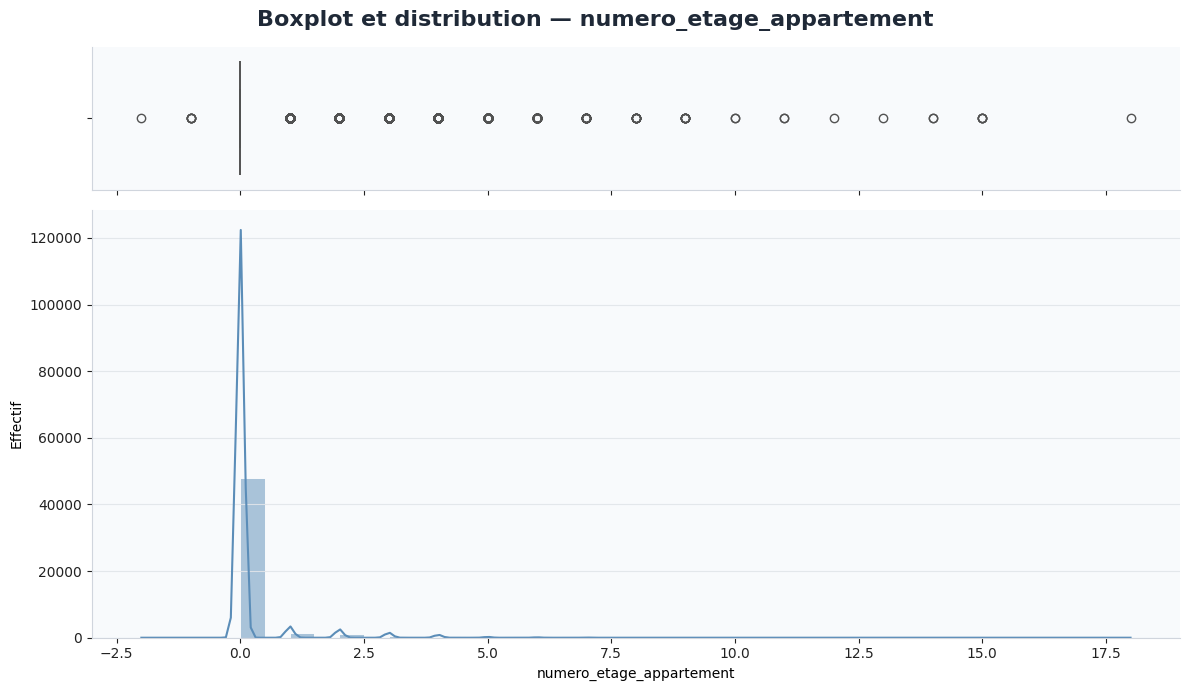

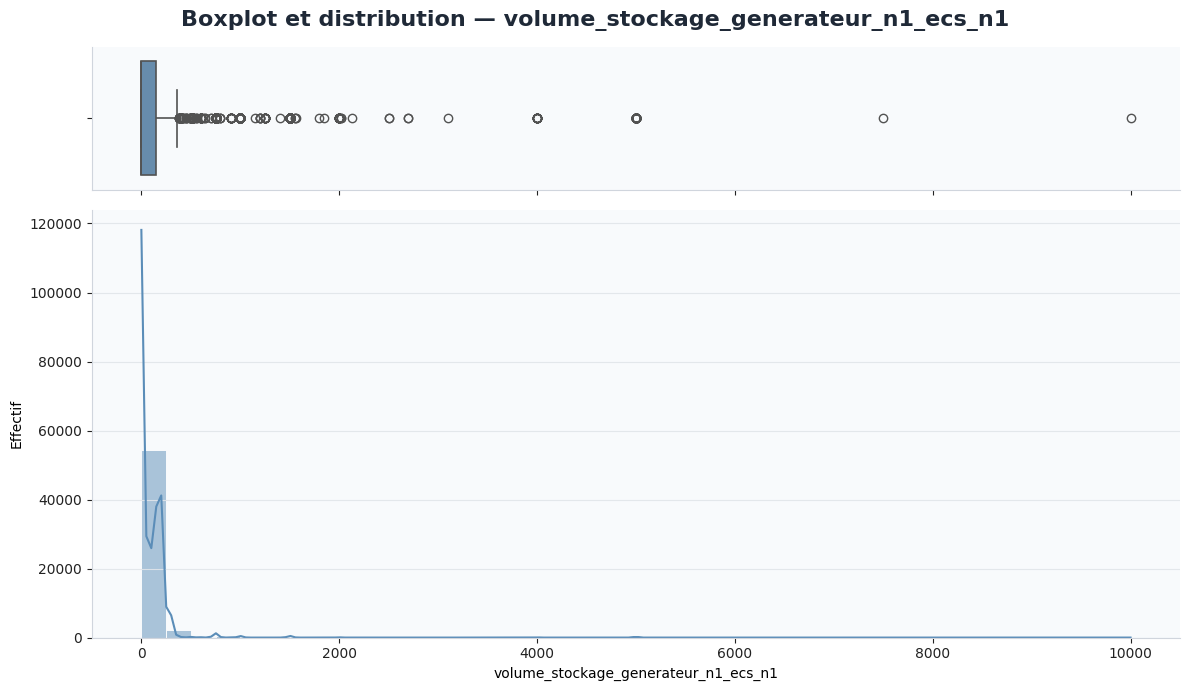

In [21]:
for col in num_cols:
    plot_boxplot_and_hist(df, col)

In [22]:
df["numero_etage_appartement"].value_counts()

numero_etage_appartement,count
f32,u32
null,6268
6.0,47
4.0,347
10.0,2
12.0,1
14.0,2
2.0,1002
8.0,9
7.0,21


In [23]:
sum(df["hauteur_sous_plafond"] > 5) + sum(df["hauteur_sous_plafond"] < 1.8)

39

# Un premier nettoyage sur les variables quantitatives avant d'aller plus loin

In [24]:
df = nettoyage_metier(df)

In [25]:
df.shape

(57103, 40)

In [26]:
new_cols_num = ["hauteur_sous_plafond_corrigee"]
var_bianire = [*var_binaire, *["has_PV"]]

num_cols = num_cols + new_cols_num

In [27]:
outlier_cols = describe_variables_numeriques(df, num_cols)

### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""hauteur_sous_plafond""",57103,0,0.0,42,2.558,1.682,1.9,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16417,28.75
"""production_electricite_pv_kwhep_par_an""",57103,0,0.0,395,42.656,1989.671,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,582,1.02
"""numero_etage_appartement""",50922,6181,10.82,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3427,6.0
"""volume_stockage_generateur_n1_ecs_n1""",56876,227,0.4,761,77.838,103.867,0.0,0.0,0.0,150.0,5000.0,150.0,-225.0,375.0,137,0.24
"""hauteur_sous_plafond_corrigee""",57103,0,0.0,42,2.545,0.173,1.9,2.5,2.5,2.5,6.0,0.0,2.5,2.5,16417,28.75


### Visualisation de la variavle hauteur_sous_plafond_corrigee

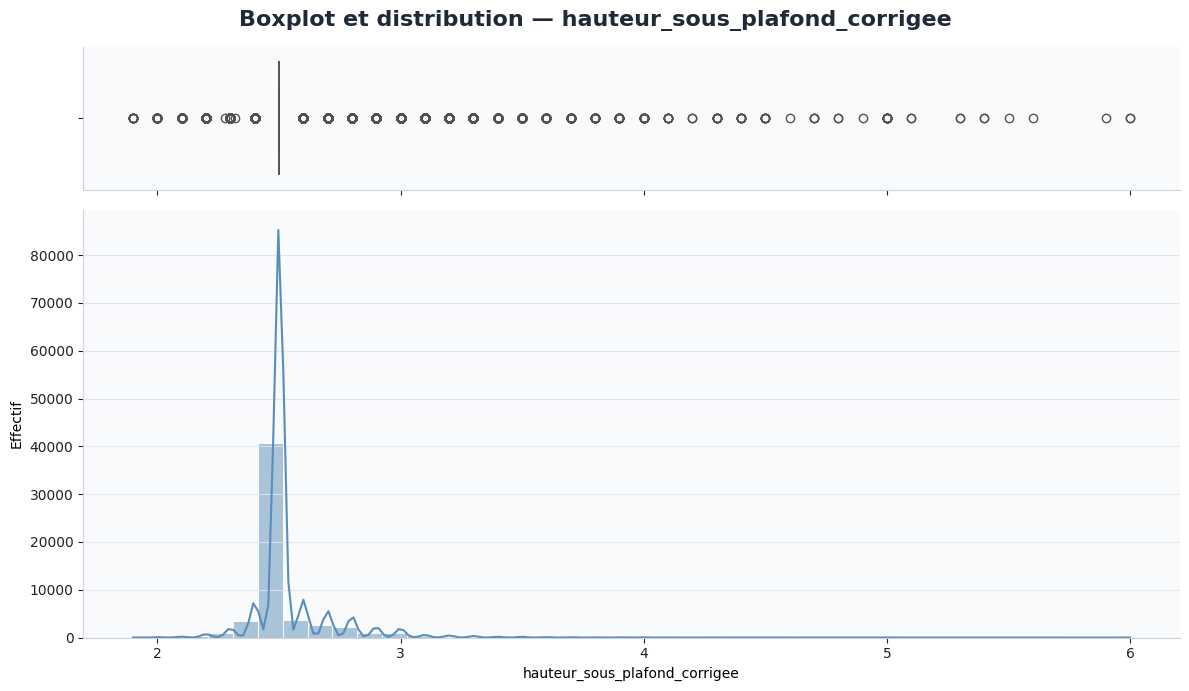

WindowsPath('src/plots/num/boxplot_distribution_hauteur_sous_plafond_corrigee.png')

In [28]:
plot_boxplot_and_hist(df, col="hauteur_sous_plafond_corrigee")

# Visualisation de la target

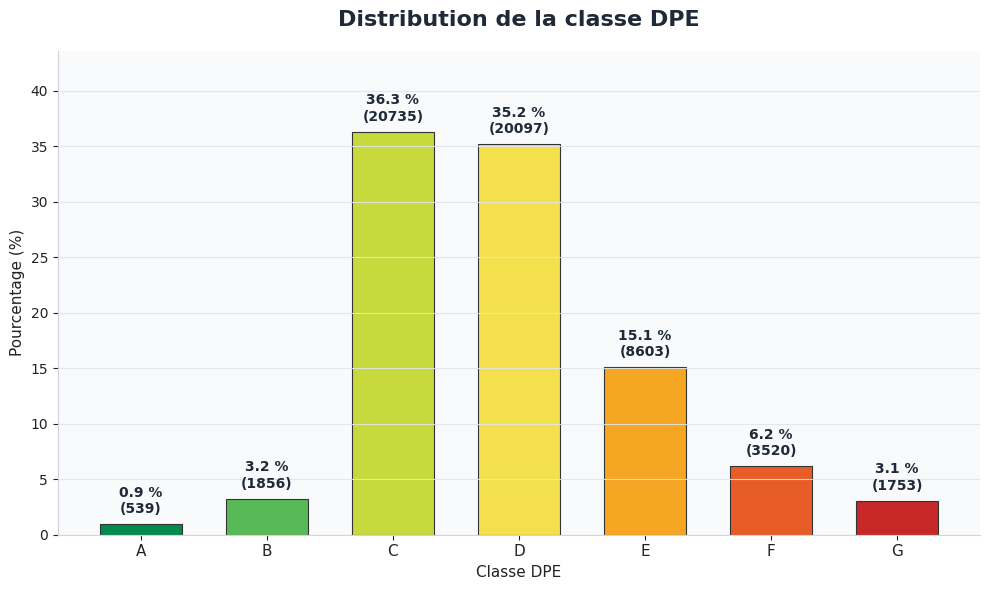

WindowsPath('src/plots/cat/distribution_etiquette_dpe.png')

In [29]:
plot_target_dpe(df, classes_dpe=CLASSES_DPE, dpe_colors=DPE_COLORS, target_col="etiquette_dpe")

# Regroupement de la target

In [30]:
df = creer_target_dpe_4_classes(df)
NEW_TARGET = "classe_dpe_4"
NEW_CLASSES_DPE = ["tres_performant", "performant", "intermediaire", "energivore"]

NEW_DPE_COLORS = {
    "tres_performant": "#008A4B",
    "performant": "#C7D93D",
    "intermediaire": "#F4E04D",
    "energivore": "#C62828",
}

TARGET_ORDER = [
    "tres_performant",
    "performant",
    "intermediaire",
    "energivore",
]

df = df.drop(TARGET)
cat_cols.remove(TARGET)

### Visualisation de la nouvelle target

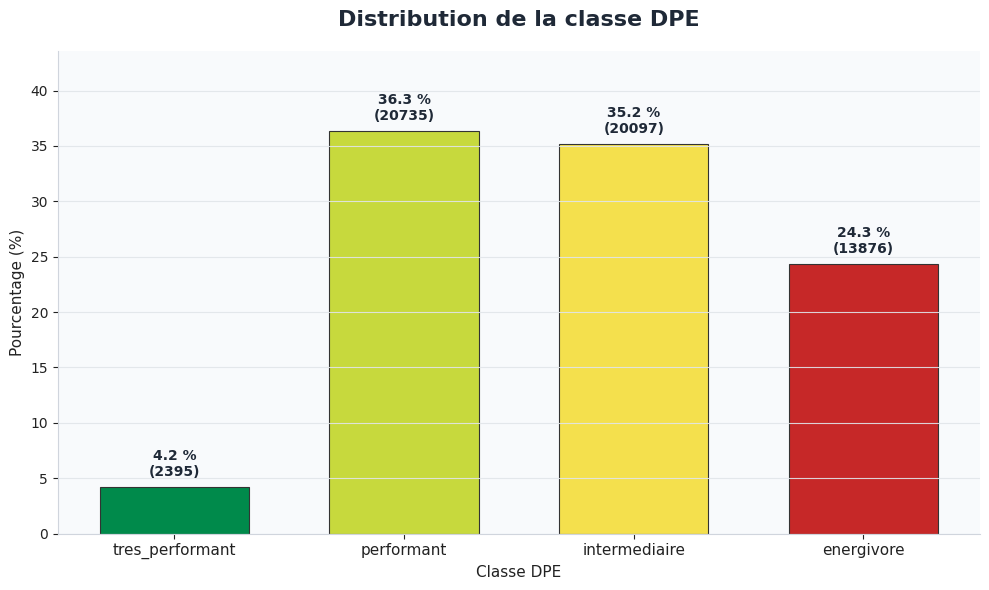

WindowsPath('src/plots/cat/distribution_classe_dpe_4.png')

In [31]:
plot_target_dpe(df, classes_dpe=NEW_CLASSES_DPE, dpe_colors=NEW_DPE_COLORS, target_col=NEW_TARGET)

# Préparation de l'analyse bivariée

## Regroupement des variables catégorielles

In [32]:
df = appliquer_regroupements_modalites(
    df=df,
    modalites_groupings=MODALITES_GROUPINGS
)

In [33]:
new_var_to_drop = list(MODALITES_GROUPINGS.keys()) + ["etiquette_dpe", "hauteur_sous_plafond", "numero_etage_appartement"]

var_to_drop = [*var_to_drop, *new_var_to_drop]

num_cols.remove("hauteur_sous_plafond")

In [34]:
colonnes_quali_regroupees = [
    f"{col}_regroupee"
    for col in MODALITES_GROUPINGS.keys()
]

colonnes_quali_regroupees

['zone_climatique_regroupee',
 'type_generateur_n1_installation_n1_regroupee',
 'type_emetteur_installation_chauffage_n1_regroupee',
 'type_generateur_n1_ecs_n1_regroupee',
 'type_energie_principale_chauffage_regroupee',
 'type_energie_principale_ecs_regroupee',
 'configuration_installation_chauffage_n1_regroupee']

## Checking des regroupements

In [35]:
controle_regroupements_modalites(
    df=df,
    colonnes_regroupees=colonnes_quali_regroupees
)

colonne,nb_modalites,missing_count,missing_%,autre_count,autre_%
str,i64,i64,f64,i64,f64
"""zone_climatique_regroupee""",3,0,0.0,0,0.0
"""type_generateur_n1_installation_n1_regroupee""",14,26,0.05,0,0.0
"""type_emetteur_installation_chauffage_n1_regroupee""",13,26,0.05,0,0.0
"""type_generateur_n1_ecs_n1_regroupee""",16,227,0.4,0,0.0
"""type_energie_principale_chauffage_regroupee""",7,0,0.0,0,0.0
"""type_energie_principale_ecs_regroupee""",8,0,0.0,0,0.0
"""configuration_installation_chauffage_n1_regroupee""",7,26,0.05,0,0.0


## Discrétisation de la variable production_electricite_pv_kwhep_par_an

### Distribution de la variable

In [36]:
resume_production_pv_positive(df)

nb_valeurs_positives,min,q25,mediane,q75,q90,q95,q99,max
u32,f32,f32,f32,f32,f32,f32,f32,f32
582,95.800003,818.099976,2138.600098,4938.299805,7502.600098,9646.099609,14688.0,460380.8125


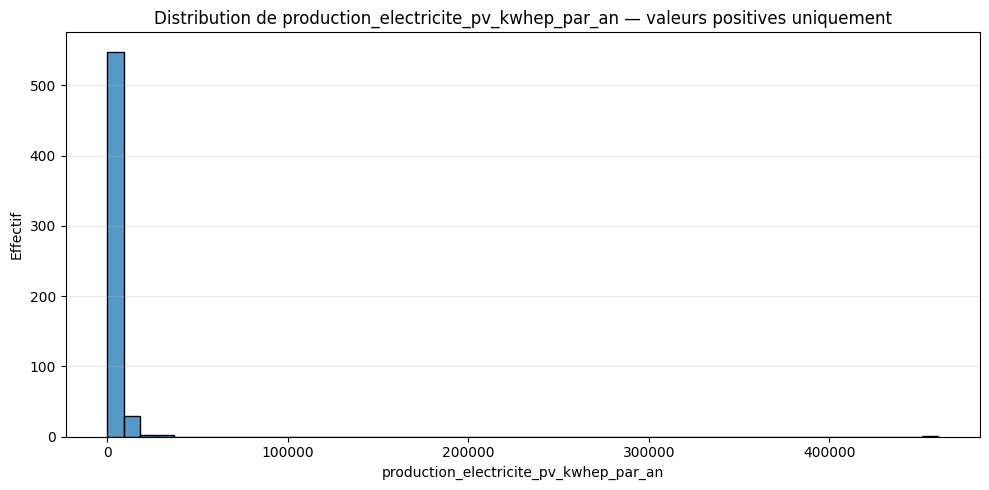

WindowsPath('src/plots/num/distribution_production_electricite_pv_kwhep_par_an_positives.png')

In [37]:
plot_dist(df, col="production_electricite_pv_kwhep_par_an", positive_only=True)

### Distribution sans le max

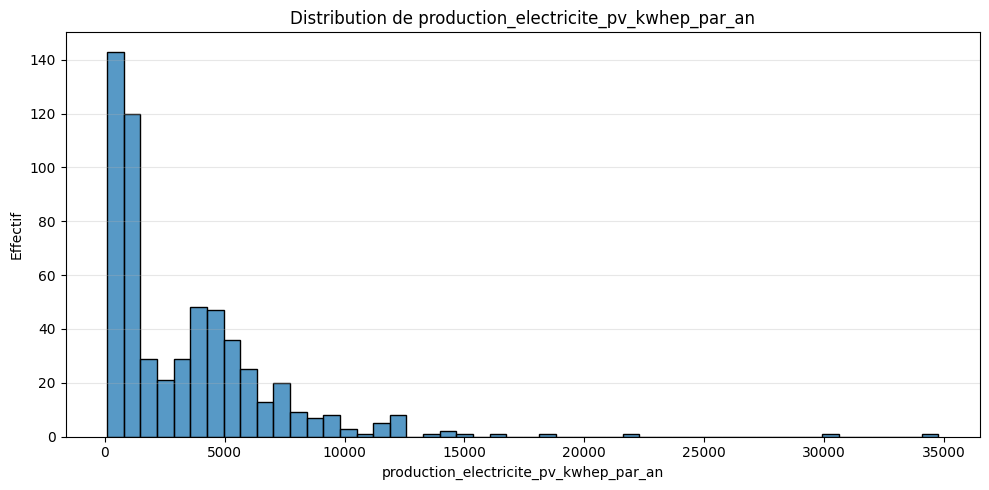

In [38]:
col = "production_electricite_pv_kwhep_par_an"

out_dir = Path("src/plots/num")
filename = f"Dist {col} without max"

fig_path = out_dir / filename

values = df.get_column(col).drop_nulls()

values = values.filter((values > 0) & (values < values.max()))

values = values.to_numpy()

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

sns.histplot(
    values,
    bins=50,
    kde=False,
    ax=ax
)

titre = f"Distribution de {col}"

ax.set_title(titre)
ax.set_xlabel(col)
ax.set_ylabel("Effectif")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    transparent=False,
)

plt.show()


### Discrétidation avec Kmeans

#### Train test split

In [39]:
train_df, test_df = split_train_test_polars(
    df,
    target="classe_dpe_4",
    test_size=0.2,
    random_state=42
)

In [40]:
print("Train :", train_df.shape)
print("Test :", test_df.shape)

Train : (45682, 47)
Test : (11421, 47)


In [41]:
train_df[NEW_TARGET].value_counts(normalize=True)

classe_dpe_4,proportion
str,f64
"""intermediaire""",0.351933
"""tres_performant""",0.041942
"""energivore""",0.243006
"""performant""",0.363119


In [42]:
test_df[NEW_TARGET].value_counts(normalize=True)

classe_dpe_4,proportion
str,f64
"""intermediaire""",0.351983
"""performant""",0.363103
"""energivore""",0.242973
"""tres_performant""",0.04194


#### Seuil avec Elbow

In [43]:
k_means = KMeans(random_state=42)

In [44]:
X_pv = (
    train_df
    .filter(pl.col(col) > 0)
    .select(col)
    .to_numpy()
)

X_pv_log = np.log1p(X_pv)

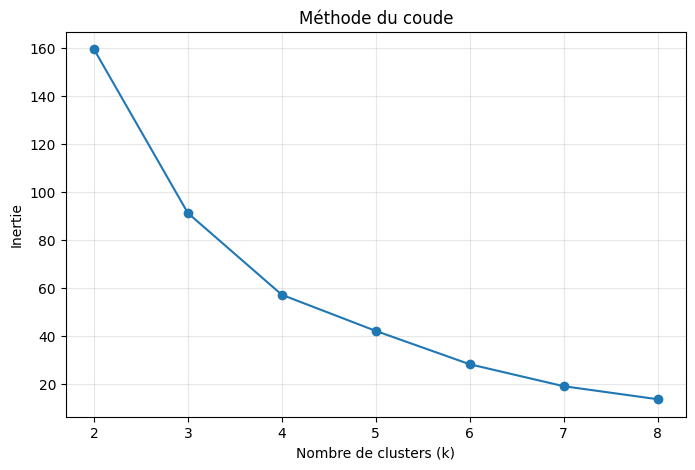

In [45]:
k_range, inertias = elbow_plot(
    X_pv_log,
    k_min=2,
    k_max=8
)

In [46]:
col_pv = "production_pv_kmeans"

In [47]:
kmeans_pv, mapping_pv = fit_kmeans_pv_train(
    train_df,
    col=col,
    n_clusters=3,
    random_state=42
)

# sur le train
train_df = appliquer_kmeans_pv(
    train_df,
    kmeans=kmeans_pv,
    mapping_cluster=mapping_pv,
    col=col
)

# Sur le test
test_df = appliquer_kmeans_pv(
    test_df,
    kmeans=kmeans_pv,
    mapping_cluster=mapping_pv,
    col=col
)

In [48]:
train_df[col_pv].value_counts(normalize=True)

production_pv_kmeans,proportion
str,f64
"""pv_faible""",0.00232
"""pv_elevee""",0.004882
"""pv_moyenne""",0.002955
"""aucune_production_pv""",0.989843


In [49]:
test_df[col_pv].value_counts(normalize=True)

production_pv_kmeans,proportion
str,f64
"""aucune_production_pv""",0.989668
"""pv_faible""",0.002539
"""pv_moyenne""",0.00324
"""pv_elevee""",0.004553


In [50]:
var_to_drop.append("production_electricite_pv_kwhep_par_an")

In [51]:
num_cols.remove("production_electricite_pv_kwhep_par_an")
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'hauteur_sous_plafond_corrigee']

# Analyse Bivariée

### Proportion des logements énergivores par départment

In [52]:
taux_energivore_par_modalite(
    df,
    col="code_postal_ban",
    target=NEW_TARGET,
    min_effectif=50,
)

code_postal_ban,effectif_modalite,effectif_energivore,taux_energivore_%
str,u32,u32,f64
"""60270""",122,83,68.03
"""80400""",78,46,58.97
"""2140""",128,75,58.59
"""59570""",106,57,53.77
"""59138""",82,43,52.44
"""2800""",170,88,51.76
"""2300""",192,99,51.56
"""80200""",103,52,50.49
"""59158""",60,29,48.33


### Energie principale utilisée pour le chauffage par type de bâtiment

In [53]:
tableau_quali_quali(
    df,
    "type_batiment",
    "type_energie_principale_chauffage_regroupee"
)

type_batiment,type_energie_principale_chauffage_regroupee,effectif,effectif_col1,pourcentage_dans_col1
str,str,u32,u32,f64
"""appartement""","""Gaz naturel""",13590,27840,48.81
"""appartement""","""Électricité""",10043,27840,36.07
"""appartement""","""Réseau de chaleur""",3981,27840,14.3
"""appartement""","""Fioul domestique""",144,27840,0.52
"""appartement""","""Bois""",57,27840,0.2
"""appartement""","""GPL / Propane / Butane""",25,27840,0.09
"""immeuble""","""Gaz naturel""",863,1681,51.34
"""immeuble""","""Électricité""",659,1681,39.2
"""immeuble""","""Réseau de chaleur""",140,1681,8.33


### Un lien entre les variables numériques

In [54]:
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'hauteur_sous_plafond_corrigee']

In [55]:
df[num_cols].drop_nulls().corr()

numero_etage_appartement,volume_stockage_generateur_n1_ecs_n1,hauteur_sous_plafond_corrigee
f64,f64,f64
1.0,-0.037472,-0.021237
-0.037472,1.0,0.044249
-0.021237,0.044249,1.0


### Des hauteurs de sous plafond diffèrent-elles entre les classes énergétiques ?

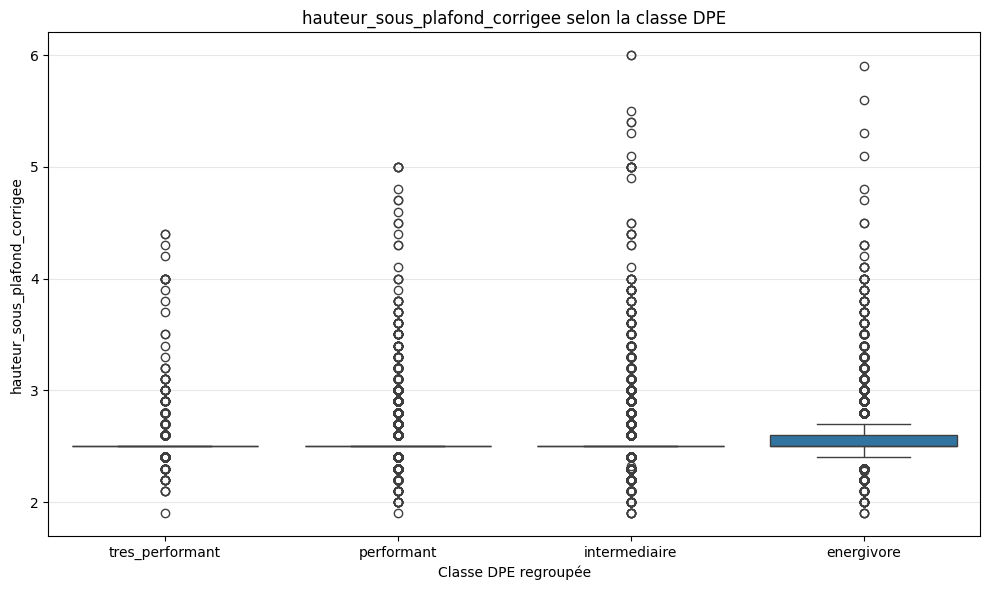

WindowsPath('src/plots/bivariee/boxplot_hauteur_sous_plafond_corrigee_vs_classe_dpe_4.png')

In [56]:
boxplot_vs_target(
    df,
    col="hauteur_sous_plafond_corrigee",
    target=NEW_TARGET,
    target_order=TARGET_ORDER
)

In [57]:
df["hauteur_sous_plafond_corrigee"].value_counts()

hauteur_sous_plafond_corrigee,count
f32,u32
3.3,152
3.2,205
5.5,1
4.6,1
2.1,91
2.3,925
2.4,1
2.7,2657
3.0,915


# Tests Statistiques pour la sélection de variables

In [58]:
var_to_drop.remove(TARGET)
train_df = train_df.drop(var_to_drop)
test_df = test_df.drop(var_to_drop)
df = df.drop(var_to_drop)

cat_cols = list(set(cat_cols) - set(var_to_drop))
num_cols = list(set(num_cols) - set(var_to_drop))

In [59]:
quali_bin_cols, quanti_cols = separer_variables_quali_bin_quanti(
    df=train_df,
    target=TARGET,
    cols_a_exclure=[NEW_TARGET],
)

In [60]:
cat_cols = quali_bin_cols
num_cols = quanti_cols

In [61]:
resultats_tests = tester_variables_avec_target(
    df=train_df,
    target=NEW_TARGET,
    cat_cols=cat_cols,
    numeric_cols=num_cols,
    tester_missing=True,
)

resultats_tests_clean = resultats_tests.filter(
    pl.col("interpretation") != "aucun_missing"
)

resultats_variables = resultats_tests_clean.filter(
    ~pl.col("variable").str.ends_with("_missing")
)

resultats_variables

variable,type_variable,test,n,nb_modalites,statistique,p_value,taille_effet,effet,interpretation,nb_groupes
str,str,str,i64,i64,f64,f64,f64,str,str,i64
"""ventilation_posterieure_2012""","""qualitative""","""chi2""",45682,2,6822.5835,0.0,0.3865,"""cramers_v""","""forte""",null
"""type_generateur_n1_ecs_n1_regroupee""","""qualitative""","""chi2""",45682,17,18126.2216,0.0,0.3637,"""cramers_v""","""forte""",null
"""qualite_isolation_murs""","""qualitative""","""chi2""",45682,5,15713.902,0.0,0.3386,"""cramers_v""","""forte""",null
"""type_generateur_n1_installation_n1_regroupee""","""qualitative""","""chi2""",45682,15,15114.4785,0.0,0.3321,"""cramers_v""","""forte""",null
"""qualite_isolation_enveloppe""","""qualitative""","""chi2""",45682,4,14814.7413,0.0,0.3288,"""cramers_v""","""forte""",null
"""periode_construction""","""qualitative""","""chi2""",45682,10,12170.9427,0.0,0.298,"""cramers_v""","""moderee""",null
"""qualite_isolation_menuiseries""","""qualitative""","""chi2""",45682,4,10367.0111,0.0,0.275,"""cramers_v""","""moderee""",null
"""qualite_isolation_plancher_bas""","""qualitative""","""chi2""",45682,5,6197.7784,0.0,0.2127,"""cramers_v""","""moderee""",null
"""type_energie_principale_chauffage_regroupee""","""qualitative""","""chi2""",45682,7,5068.7455,0.0,0.1923,"""cramers_v""","""moderee""",null


In [62]:
variables_a_garder = [
    # Ventilation
    "ventilation_posterieure_2012",

    # ECS
    "type_generateur_n1_ecs_n1_regroupee",
    "type_energie_principale_ecs_regroupee",
    "usage_generateur_n1_ecs_n1",
    "volume_stockage_generateur_n1_ecs_n1",

    # Chauffage
    "type_generateur_n1_installation_n1_regroupee",
    "type_energie_principale_chauffage_regroupee",
    "type_emetteur_installation_chauffage_n1_regroupee",

    # Isolation / bâti
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "qualite_isolation_plancher_bas",
    "periode_construction",
    "type_batiment",

    # PV
    "has_PV",

    # Numérique
    "hauteur_sous_plafond_corrigee",
]

In [63]:
variables_optionnelles = [
    "usage_generateur_n1_installation_n1",
    "configuration_installation_chauffage_n1_regroupee",
    "classe_inertie_batiment",
    "production_pv_kmeans",
    "type_installation_chauffage_n1",
    "type_installation_ecs_n1",
    "type_installation_solaire_n1",
    "configuration_installation_ecs_n1",
]

In [64]:
variables_a_supprimer = [
    "classe_altitude",
    "numero_etage_appartement_corrige",
    "zone_climatique_regroupee",
    "qualite_isolation_enveloppe",
]

In [65]:
features_v1 = variables_a_garder
features_v2 = variables_a_garder + variables_optionnelles

In [66]:
train_df = train_df.drop(variables_a_supprimer)
test_df = test_df.drop(variables_a_supprimer)
df = df.drop(variables_a_supprimer)

cat_cols = list(set(cat_cols) - set(variables_a_supprimer))
num_cols = list(set(num_cols) - set(variables_a_supprimer))

# Preprocessing

In [67]:
X_train = train_df.drop(NEW_TARGET)
y_train = train_df[NEW_TARGET]
X_test = test_df.drop(NEW_TARGET)
y_test = test_df[NEW_TARGET]

## Gestion des valeurs manquantes 

### Visualation des valeurs manquantes par variable

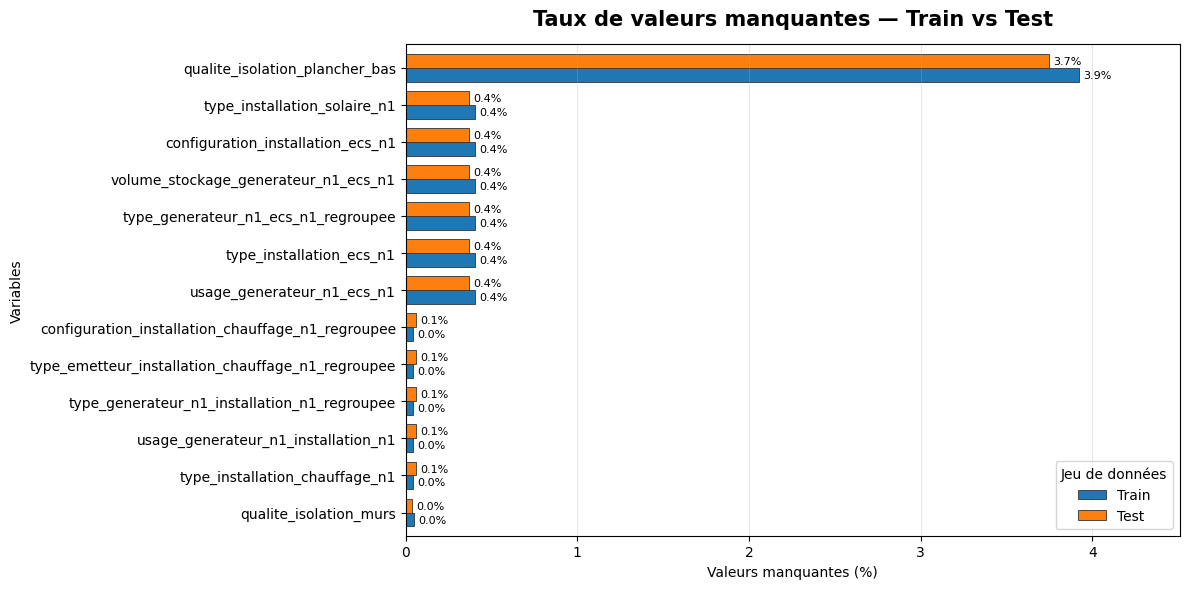

WindowsPath('src/plots/missing/missing_values_train_test.png')

In [68]:
plot_missing_train_test(
    X_train,
    X_test,
    only_missing=True,
    top_n=None,
    verbose=True,
)

### Remplacement des valeurs manquantes

In [69]:
features_v1 = [
    col for col in features_v1
    if col in train_df.columns
]

X_train = train_df.select(features_v1)
y_train = train_df[NEW_TARGET].to_numpy()

X_test = test_df.select(features_v1)
y_test = test_df[NEW_TARGET].to_numpy()

In [70]:
cat_cols_v1 = [
    col for col in cat_cols
    if col in X_train.columns
]

num_cols_v1 = [
    col for col in num_cols
    if col in X_train.columns
]

In [71]:
numeric_cols_missing = colonnes_avec_missing(
    X_train,
    num_cols_v1
)

X_train = imputer_apres_selection(
    X_train,
    cat_cols=cat_cols_v1,
    numeric_cols=num_cols_v1,
    numeric_cols_missing=numeric_cols_missing,
)

X_test = imputer_apres_selection(
    X_test,
    cat_cols=cat_cols_v1,
    numeric_cols=num_cols_v1,
    numeric_cols_missing=numeric_cols_missing,
)

In [72]:
# Vérification
cols_miss = X_train.select(cs.ends_with("_missing")).columns

X_train.select(cols_miss).sum()

volume_stockage_generateur_n1_ecs_n1_missing
i64
185


# Pipeline : Encodage + Standardisation

## Avec les premières features pertinentes retenues

In [73]:
features_model = X_train.columns

cat_cols_model, binary_cols_model, numeric_cols_model = separer_colonnes_pipeline(
    X_train,
    features_model
)

In [74]:
cat_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

num_pipeline = Pipeline(
    steps=[
        ("scaler", RobustScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, cat_cols_model),
        ("num", num_pipeline, numeric_cols_model),
        ("bin", "passthrough", binary_cols_model),
    ],
    remainder="drop"
)

In [75]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="saga",
            random_state=42
        )),
    ]
)

In [76]:
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()

In [77]:
model.fit(X_train_pd, y_train)

D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [78]:
y_pred = model.predict(X_test_pd)

## classification report

In [79]:
report_df = afficher_classification_report(
    y_test,
    y_pred,
    target_order=TARGET_ORDER,
)

,precision,recall,f1-score,support
tres_performant,0.385,0.839,0.528,479.000
performant,0.767,0.639,0.697,4147.000
intermediaire,0.582,0.471,0.520,4020.000
energivore,0.580,0.768,0.661,2775.000
accuracy,0.619,0.619,0.619,0.619
macro avg,0.579,0.679,0.602,11421.000
weighted avg,0.640,0.619,0.619,11421.000


Accuracy : 0.6194
Balanced accuracy : 0.6791
F1 macro : 0.6017


## Matrice de confusion

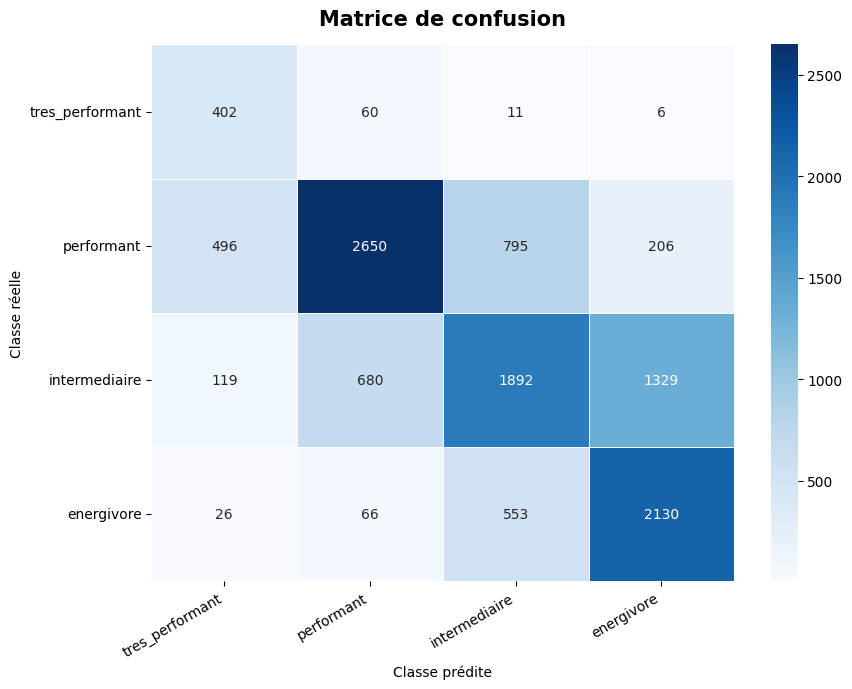

WindowsPath('src/plots/modelisation/confusion_matrix.png')

In [80]:
plot_confusion_matrix(
    y_test,
    y_pred,
    target_order=TARGET_ORDER,
    normalize=False,
)

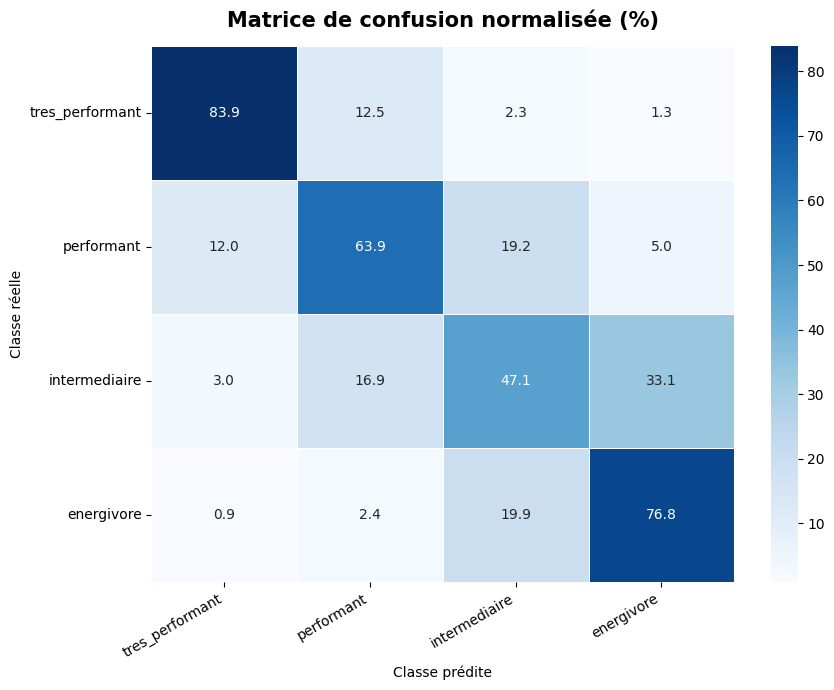

WindowsPath('src/plots/modelisation/confusion_matrix_normalisee.png')

In [81]:
plot_confusion_matrix(
    y_test,
    y_pred,
    target_order=TARGET_ORDER,
    normalize=True,
)